In [1]:
from sklearn.preprocessing import StandardScaler
from utils.evaluation import *
from utils.load_data import load_processed_data
from models.dnn import DNN
from models.linear_regression import LinearRegressionSklearn 
import torch
from torch.utils.data import DataLoader, Dataset

## Load data

In [2]:
data_path = '../data/processed'
X_train, X_val, X_test, y_train, y_val, y_test = load_processed_data(data_path)

X_train shape: torch.Size([2116, 31]), y_train shape: torch.Size([2116, 1])
X_val shape: torch.Size([454, 31]), y_val shape: torch.Size([454, 1])
X_test shape: torch.Size([454, 31]), y_test shape: torch.Size([454, 1])


In [3]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [4]:
batch_size = 32

train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

## Training and Evaluation

In [5]:
def pipeline(model, epochs=50, verbose=True, early_stopping=True, patience=10):
    train_losses, val_losses = model.fit(
        train_loader, 
        val_loader, 
        epochs=epochs, 
        verbose=verbose, 
        early_stopping=early_stopping,
        patience=patience
    )
    test_model(model, X_test, y_test)
    plot_loss(train_losses, val_losses)

#### Hyperparameters

In [6]:
epochs = 300
learning_rate = 0.001
dropout = 0.1
batch_norm = True
l2_lambda = 0.001

### Linear Regression

In [7]:
lr = LinearRegressionSklearn()
lr.fit(X_train, y_train)
test_model(lr, X_test, y_test)


========= Model Evaluation =========
Mean Squared Error (MSE): 173.3573
R^2 Score: 0.7881


### DNN-16

In [8]:
dnn_16 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[16],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda
)
dnn_16.model

Sequential(
  (0): Linear(in_features=31, out_features=16, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=16, out_features=1, bias=True)
)

Epoch [30/300], Train Loss: 204.9604, Val Loss: 235.3783
Early stopping at epoch 40

========= Model Evaluation =========
Mean Squared Error (MSE): 326.8878
R^2 Score: 0.6004


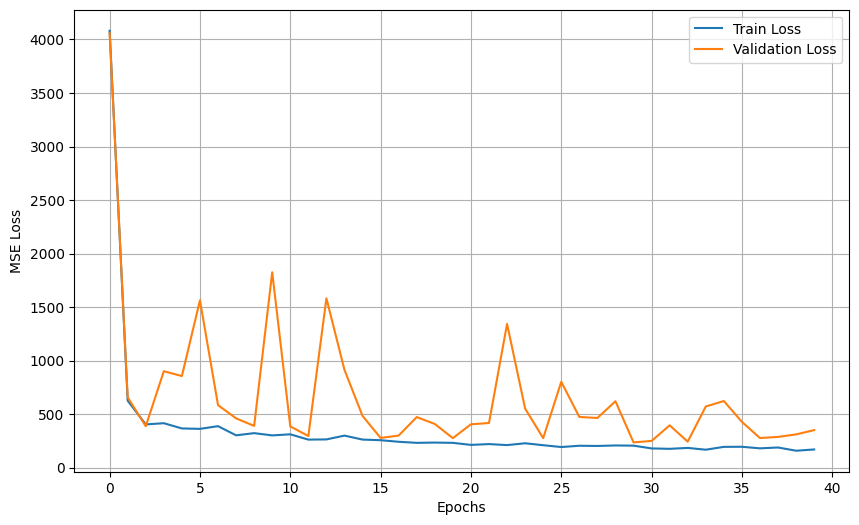

In [9]:
pipeline(dnn_16, epochs=epochs)

## DNN-30-8

In [10]:
dnn_30_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 8],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda
)
dnn_30_8.model

Sequential(
  (0): Linear(in_features=31, out_features=30, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=30, out_features=8, bias=True)
  (3): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): LeakyReLU(negative_slope=0.01)
  (5): Dropout(p=0.1, inplace=False)
  (6): Linear(in_features=8, out_features=1, bias=True)
)

Early stopping at epoch 24

========= Model Evaluation =========
Mean Squared Error (MSE): 943.2405
R^2 Score: -0.1530


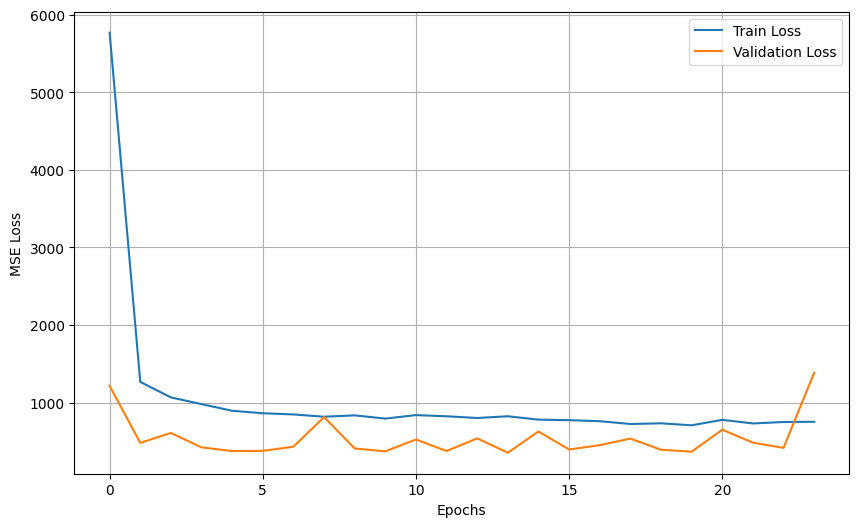

In [11]:
pipeline(dnn_30_8, epochs=epochs)

## DNN-30-16-8

In [12]:
dnn_30_16_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 16, 8],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda
)
dnn_30_16_8.model

Sequential(
  (0): Linear(in_features=31, out_features=30, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=30, out_features=16, bias=True)
  (3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): LeakyReLU(negative_slope=0.01)
  (5): Dropout(p=0.1, inplace=False)
  (6): Linear(in_features=16, out_features=8, bias=True)
  (7): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): LeakyReLU(negative_slope=0.01)
  (9): Dropout(p=0.1, inplace=False)
  (10): Linear(in_features=8, out_features=1, bias=True)
)

Early stopping at epoch 25

========= Model Evaluation =========
Mean Squared Error (MSE): 382.2663
R^2 Score: 0.5327


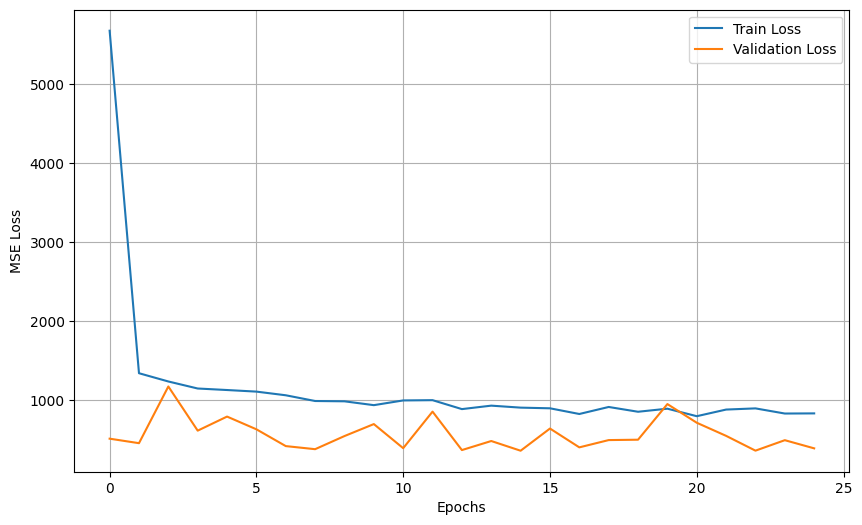

In [13]:
pipeline(dnn_30_16_8, epochs=epochs)

## DNN-30-16-8-4

In [14]:
dnn_30_16_8_4 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 16, 8, 4],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda
)
dnn_30_16_8_4.model

Sequential(
  (0): Linear(in_features=31, out_features=30, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=30, out_features=16, bias=True)
  (3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): LeakyReLU(negative_slope=0.01)
  (5): Dropout(p=0.1, inplace=False)
  (6): Linear(in_features=16, out_features=8, bias=True)
  (7): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): LeakyReLU(negative_slope=0.01)
  (9): Dropout(p=0.1, inplace=False)
  (10): Linear(in_features=8, out_features=4, bias=True)
  (11): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): LeakyReLU(negative_slope=0.01)
  (13): Dropout(p=0.1, inplace=False)
  (14): Linear(in_features=4, out_features=1, bias=True)
)

Early stopping at epoch 18

========= Model Evaluation =========
Mean Squared Error (MSE): 416.0277
R^2 Score: 0.4914


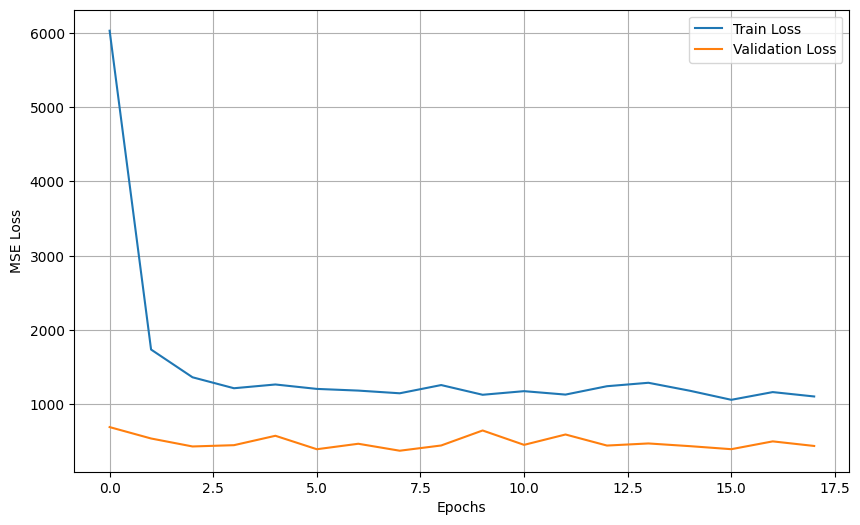

In [15]:
pipeline(dnn_30_16_8_4, epochs=epochs)

## DNN-64-32-16-8

In [16]:
dnn_64_32_16_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[64, 32, 16, 8],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda
)
dnn_64_32_16_8.model

Sequential(
  (0): Linear(in_features=31, out_features=64, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): LeakyReLU(negative_slope=0.01)
  (5): Dropout(p=0.1, inplace=False)
  (6): Linear(in_features=32, out_features=16, bias=True)
  (7): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): LeakyReLU(negative_slope=0.01)
  (9): Dropout(p=0.1, inplace=False)
  (10): Linear(in_features=16, out_features=8, bias=True)
  (11): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): LeakyReLU(negative_slope=0.01)
  (13): Dropout(p=0.1, inplace=False)
  (14): Linear(in_features=8, out_features=1, bias=True)
)

Early stopping at epoch 24

========= Model Evaluation =========
Mean Squared Error (MSE): 510.9178
R^2 Score: 0.3755


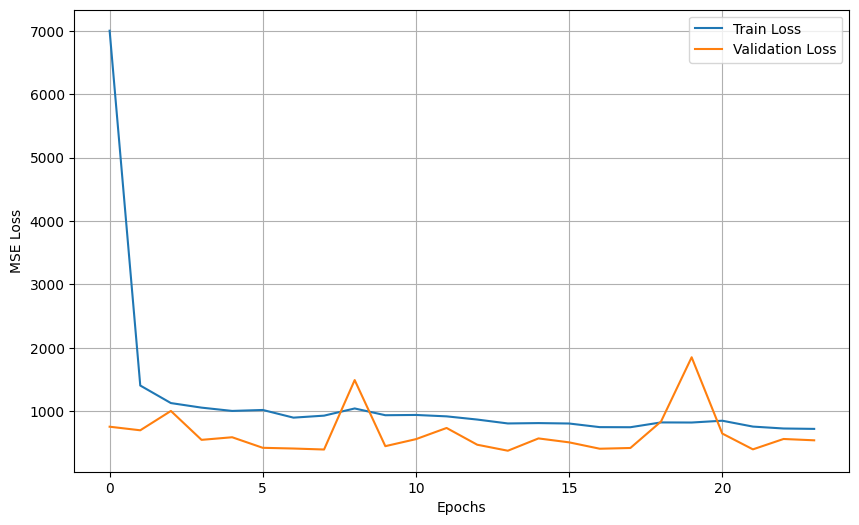

In [17]:
pipeline(dnn_64_32_16_8, epochs=epochs)